# Buy Box e margem: o que os dados dizem

**Data da analise:** 2026-09-19 · **Painel:** 28 dias (2026-08-22 a 2026-09-19) · **Fonte:** `market_offers` no R2

---

## A pergunta de negocio

O cliente quer **maximizar o tempo em que seus SKUs ficam na buy box sem destruir margem**.
Essa frase esconde tres perguntas separaveis, e uma quarta que so apareceu quando a carteira
real entrou no dataset:

1. **O que faz uma oferta ganhar a buy box?** Se fosse so preco, a resposta seria trivial.
2. **Quanto vale, em reais, cada atributo que nao e preco?** E o que transforma o modelo em decisao.
3. **Ganhar a buy box dura?** Se durasse um dia, pagar para conquista-la nao se justificaria.

## O que mudou desde a versao de 2026-09-12

- **Painel de 22 -> 28 dias.** Um dia sem coleta (15/09) e um snapshot parcial (19/09) exigiram
  tratamento explicito: sem isso, a retencao da secao 7 sai subestimada.
- **A estimacao dinamica passou a viver aqui.** Os coeficientes que `services/price_model.py` usa
  em producao vinham de uma estimacao que nao estava versionada em lugar nenhum. A secao 6
  reconstroi e documenta. **Os numeros mudaram** - ver o comparativo la.
- **A analise da carteira saiu deste notebook.** Ela depende de dado comercial do
  cliente e o repositorio e publico, entao vive em `02_carteira_cliente.ipynb`, que
  esta no `.gitignore`. Aqui fica so o mercado agregado.
- **`custo_compra` continua vazio.** A secao 9 segue parametrizada, nao resolvida.

---
## 1. Setup e carga

In [1]:
import sys, io, os, json, logging, warnings, math
from datetime import date
warnings.filterwarnings("ignore")
logging.disable(logging.INFO)

# o notebook vive em notebooks/; os modulos de storage vivem em etl/
ETL = os.path.abspath(os.path.join(os.getcwd(), "..", "etl"))
if ETL not in sys.path:
    sys.path.insert(0, ETL)

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

from storage.r2 import get_client, download_bytes
from src.config import R2_BUCKET
from services import client_config

print("polars", pl.__version__, "| bucket:", R2_BUCKET)

polars 1.43.2 | bucket: orus-github-actions


In [2]:
# --- paleta (validada com scripts/validate_palette.js da skill dataviz) ---
AZUL, LARANJA, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
TINTA, TINTA2, GRADE = "#0b0b0b", "#52514e", "#e5e4e0"

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": GRADE, "axes.labelcolor": TINTA2, "text.color": TINTA,
    "xtick.color": TINTA2, "ytick.color": TINTA2, "axes.grid": True,
    "grid.color": GRADE, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "figure.dpi": 110,
})

In [3]:
def listar(prefixo):
    c = get_client(); chaves = []; tok = None
    while True:
        kw = dict(Bucket=R2_BUCKET, Prefix=prefixo)
        if tok: kw["ContinuationToken"] = tok
        r = c.list_objects_v2(**kw)
        chaves += [o["Key"] for o in r.get("Contents", [])]
        if not r.get("IsTruncated"): break
        tok = r.get("NextContinuationToken")
    return sorted(chaves)

todas = listar("market_offers/")
# alguns dias tem mais de um snapshot (re-runs). Manter 1 por dia, senao o painel
# da secao 7 compara o dia consigo mesmo e INFLA a retencao artificialmente.
por_dia = {}
for k in todas:
    por_dia[k.split('date=')[1][:10]] = k          # sorted() garante: fica o ultimo
dias = sorted(por_dia)
print(f"{len(todas)} arquivos -> {len(dias)} dias unicos ({len(todas)-len(dias)} re-runs descartadas)")
print("mais antigo:", dias[0], "| mais recente:", dias[-1])

# lacunas de calendario: importam na secao 7
d0, d1 = date.fromisoformat(dias[0]), date.fromisoformat(dias[-1])
faltando = [str(date.fromordinal(o)) for o in range(d0.toordinal(), d1.toordinal()+1)
            if str(date.fromordinal(o)) not in por_dia]
print("dias do calendario sem coleta:", faltando or "nenhum")

32 arquivos -> 29 dias unicos (3 re-runs descartadas)
mais antigo: 2026-08-22 | mais recente: 2026-09-20
dias do calendario sem coleta: ['2026-09-15']


### 1.1 Nem todo snapshot e um retrato do mercado

Um dia pode ser coletado sob demanda, com **apenas um punhado de categorias**, para uma
analise pontual. Um dia assim nao e comparavel a um dia de cron, que varre ~200 categorias.

Misturar os dois quebra duas coisas de formas diferentes:

- **na secao cruzada** ("o mercado hoje"), um dia parcial nao representa o mercado;
- **no painel**, um produto ausente por *nao ter sido coletado* seria lido como produto que
  *sumiu* - e isso contamina a medida de retencao.

Entao: a secao cruzada usa o ultimo dia **completo**, e o painel descarta dias parciais por
volume. Uma analise restrita a poucas categorias pode usar o dia parcial de proposito - e e
o que `02_carteira_cliente.ipynb` faz.

In [4]:
def carrega(k, so_catalogo=True):
    df = pl.read_parquet(io.BytesIO(download_bytes(k)))
    # snapshots anteriores a 2026-09-12 nao tem a coluna: eram catalogo por construcao
    if "product_type" not in df.columns:
        df = df.with_columns(pl.lit("PRODUCT").alias("product_type"))
    df = df.unique(subset=["catalog_product_id", "item_id"], keep="first")
    return df.filter(pl.col("product_type") == "PRODUCT") if so_catalogo else df

tamanhos = {}
for d in dias:
    tamanhos[d] = carrega(por_dia[d]).height
mediana_dia = float(np.median(list(tamanhos.values())))
parciais = [d for d, n in tamanhos.items() if n < 0.5 * mediana_dia]
completos = [d for d in dias if d not in parciais]

print(f"mediana de linhas/dia: {mediana_dia:,.0f}")
print(f"dias parciais (< 50% da mediana): {parciais or 'nenhum'}")
for d in parciais:
    print(f"   {d}: {tamanhos[d]:,} linhas  <- coleta sob demanda, so categorias do cliente")
print(f"\nultimo dia completo: {completos[-1]}")

HOJE = por_dia[completos[-1]]
bruto = carrega(HOJE, so_catalogo=False)
dedup = bruto.filter(pl.col("product_type") == "PRODUCT")
print(f"snapshot de referencia: {bruto.height:,} linhas ({dedup.height:,} de catalogo)")

mediana de linhas/dia: 15,898
dias parciais (< 50% da mediana): ['2026-09-19']
   2026-09-19: 548 linhas  <- coleta sob demanda, so categorias do cliente

ultimo dia completo: 2026-09-20


snapshot de referencia: 15,799 linhas (15,414 de catalogo)


---
## 2. Qualidade dos dados

Antes de qualquer inferencia.

In [5]:
print("=== 2.1 Composicao por tipo de anuncio ===")
for r in bruto["product_type"].value_counts().sort("count", descending=True).iter_rows(named=True):
    print(f"  {r['product_type']:<14} {r['count']:>7,} linhas")

proprios = bruto.filter(pl.col("product_type") == "USER_PRODUCT")
if proprios.height:
    g = proprios.group_by("catalog_product_id").len()
    print(f"\n  anuncios proprios: {g.height} produtos")
    print(f"  ofertas por produto: min {g['len'].min()} | mediana {g['len'].median()} | max {g['len'].max()}")
    print("  (mediana 1 confirma: anuncio proprio nao tem concorrente na pagina)")

print(f"\n=== 2.2 Precos-lixo ===")
print(f"  preco maximo observado: R$ {bruto['price'].max():,.2f}")
spread = (dedup.group_by("catalog_product_id")
               .agg(pl.col("price").min().alias("mn"), pl.col("price").max().alias("mx"),
                    pl.len().alias("n"))
               .filter(pl.col("n") >= 2)
               .with_columns((pl.col("mx") / pl.col("mn")).alias("razao")))
absurdos = spread.filter(pl.col("razao") > 20)
print(f"  produtos com razao max/min > 20x: {absurdos.height} de {spread.height}")
print("  -> tratados pelo corte no percentil 99,5 antes de qualquer regressao")

=== 2.1 Composicao por tipo de anuncio ===
  PRODUCT         15,414 linhas
  USER_PRODUCT       385 linhas

  anuncios proprios: 358 produtos
  ofertas por produto: min 1 | mediana 1.0 | max 3
  (mediana 1 confirma: anuncio proprio nao tem concorrente na pagina)

=== 2.2 Precos-lixo ===
  preco maximo observado: R$ 399,900,039.59
  produtos com razao max/min > 20x: 10 de 885
  -> tratados pelo corte no percentil 99,5 antes de qualquer regressao


---
## 3. H1 - A buy box nao e um leilao puro de preco

Se fosse, o vencedor seria sempre a oferta mais barata. Teste direto.

In [6]:
g = dedup.group_by("catalog_product_id").len().filter(pl.col("len") >= 2)
comp = dedup.join(g.select("catalog_product_id"), on="catalog_product_id")

venc = (comp.filter(pl.col("rank") == 0)
            .unique(subset=["catalog_product_id"], keep="first")
            .select(["catalog_product_id", pl.col("price").alias("p_venc")]))
mini = comp.group_by("catalog_product_id").agg(pl.col("price").min().alias("p_min"))
h1 = venc.join(mini, on="catalog_product_id")
premium_h1 = (h1.filter(pl.col("p_venc") > pl.col("p_min"))
                .with_columns(((pl.col("p_venc") / pl.col("p_min") - 1) * 100).alias("premio")))

print(f"produtos com >= 2 ofertas: {h1.height:,}")
print(f"vencedor NAO e o mais barato: {premium_h1.height:,} ({100*premium_h1.height/h1.height:.1f}%)")
print(f"premio mediano do vencedor sobre o mais barato: +{float(premium_h1['premio'].median()):.1f}%")

produtos com >= 2 ofertas: 885
vencedor NAO e o mais barato: 208 (23.5%)
premio mediano do vencedor sobre o mais barato: +18.7%


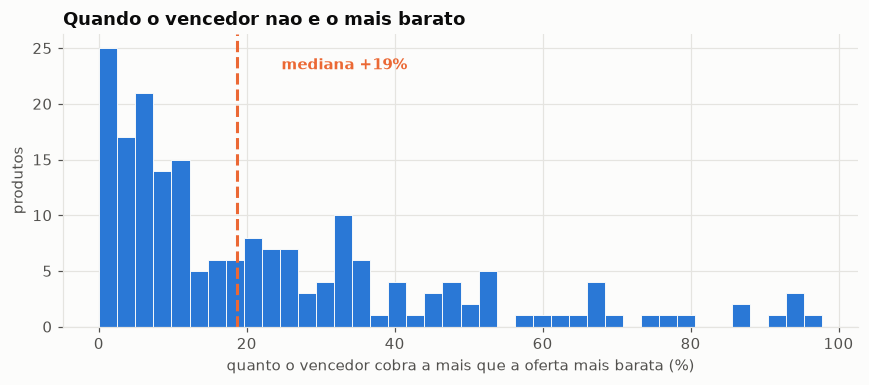

In [7]:
fig, ax = plt.subplots(figsize=(8, 3.6))
dados = premium_h1["premio"].to_numpy()
dados = dados[dados <= 100]
ax.hist(dados, bins=40, color=AZUL, edgecolor="#fcfcfb", linewidth=0.6)
med = float(premium_h1["premio"].median())
ax.axvline(med, color=LARANJA, linewidth=2, linestyle="--")
ax.annotate(f"mediana +{med:.0f}%", xy=(med, ax.get_ylim()[1]*0.88),
            xytext=(med+6, ax.get_ylim()[1]*0.88), color=LARANJA, fontweight="bold")
ax.set_xlabel("quanto o vencedor cobra a mais que a oferta mais barata (%)")
ax.set_ylabel("produtos")
ax.set_title("Quando o vencedor nao e o mais barato", fontweight="bold", loc="left")
plt.tight_layout(); plt.show()

**Veredito: H1 confirmada.** Em ~1 de cada 4 produtos o vencedor cobra mais que o rival mais
barato, com mediana de dois digitos. O ranking pondera outra coisa alem de preco - as secoes 5 e 6
medem o que e, e quanto vale.

Isso derruba a premissa implicita da estrategia `beat_winner` (bater o preco do vencedor em R$0,01):
em um quarto dos casos ela **paga a mais do que precisaria**, porque supoe uma disputa que e so preco.

---
## 4. H2 - Atributos operacionais tem preco-sombra

Se preco nao explica tudo, o que explica? A dificuldade e que produtos diferentes tem niveis de
preco diferentes, entao comparar ofertas entre produtos e ruido puro.

**Metodo: logit condicional com efeito fixo por produto.** Cada `catalog_product_id` e um grupo;
o modelo so usa variacao *dentro* do mesmo produto, comparando ofertas que disputam a mesma
pagina. O efeito fixo absorve tudo que e constante no produto (categoria, marca, faixa de preco,
demanda), e o que sobra e a diferenca entre concorrentes.

Esta secao usa **um dia** (a secao cruzada). A secao 6 refaz com o painel inteiro e acrescenta o
termo que faltava.

In [8]:
from statsmodels.discrete.conditional_models import ConditionalLogit

teto = dedup["price"].quantile(0.995)          # corta o preco-barreira da secao 2.2
base = (comp.filter(pl.col("price") <= teto)
            .join(dedup.group_by("catalog_product_id").len()
                       .filter((pl.col("len") >= 2) & (pl.col("len") <= 100))
                       .select("catalog_product_id"), on="catalog_product_id"))

base = base.with_columns([
    (pl.col("shipping_logistic_type") == "fulfillment").cast(pl.Int8).alias("full"),
    pl.col("official_store_id").is_not_null().cast(pl.Int8).alias("oficial"),
    pl.col("shipping_free").cast(pl.Int8).alias("frete_gratis"),
    (pl.col("listing_type_id") == "gold_pro").cast(pl.Int8).alias("gold_pro"),
    (pl.col("rank") == 0).cast(pl.Int8).alias("y"),
    pl.col("price").median().over("catalog_product_id").alias("p_med"),
])
base = base.with_columns(np.log(base["price"] / base["p_med"]).alias("log_preco_rel"))

# grupos precisam ter exatamente 1 vencedor e >= 2 ofertas
val = (base.group_by("catalog_product_id")
           .agg(pl.col("y").sum().alias("s"), pl.len().alias("n"))
           .filter((pl.col("s") == 1) & (pl.col("n") >= 2)))
base = base.join(val.select("catalog_product_id"), on="catalog_product_id")

REG = ["log_preco_rel", "full", "oficial", "frete_gratis", "gold_pro"]
pdf = base.select(REG + ["y", "catalog_product_id"]).to_pandas()
modelo = ConditionalLogit(pdf["y"], pdf[REG], groups=pdf["catalog_product_id"]).fit(disp=0)
print(f"amostra: {len(pdf):,} ofertas em {pdf.catalog_product_id.nunique():,} produtos\n")
print(modelo.summary())

amostra: 11,334 ofertas em 862 produtos

                  Conditional Logit Model Regression Results                  
Dep. Variable:                      y   No. Observations:                11334
Model:               ConditionalLogit   No. groups:                        862
Log-Likelihood:               -979.51   Min group size:                      2
Method:                          BFGS   Max group size:                     99
Date:                Sun, 20 Sep 2026   Mean group size:                  13.1
Time:                        23:08:56                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
log_preco_rel    -9.2318      0.426    -21.655      0.000     -10.067      -8.396
full              0.7262      0.118      6.136      0.000       0.494       0.958
oficial           1.0422      0.124      8.372      0.000       0.798       1.

### 4.1 Traduzindo coeficientes para reais

Um coeficiente de logit nao diz nada a um gerente comercial. A traducao util e o **preco-sombra**:
*quanto a mais posso cobrar, tendo o atributo, para ficar com a mesma probabilidade de buy box?*

Na indiferenca, o ganho do atributo compensa exatamente a perda de subir preco:

$$\beta_{preco}\cdot\Delta\ln(p) + \beta_{atributo} = 0
\quad\Longrightarrow\quad
\theta = -\frac{\beta_{atributo}}{\beta_{preco}}
\quad\Longrightarrow\quad
\text{premio \%} = (e^{\theta}-1)\times 100$$

$\theta$ e uma **razao de dois estimadores**. Transformar so os extremos do IC de $\beta_{atributo}$
trataria $\beta_{preco}$ como conhecido e ignoraria $\mathrm{Cov}(\beta_k,\beta_{preco})$ - por isso
o IC abaixo sai pelo **delta method**.

In [9]:
def tabela_sombra(modelo, REG, rotulos):
    b  = dict(zip(REG, modelo.params)); se = dict(zip(REG, modelo.bse))
    V  = np.asarray(modelo.cov_params()); ix = {k: i for i, k in enumerate(REG)}
    bp = b["log_preco_rel"]; iP = ix["log_preco_rel"]

    def premio_ic(k):
        th  = -b[k] / bp
        d_k = -1.0 / bp                      # d(theta)/d(b_k)
        d_p =  b[k] / bp**2                  # d(theta)/d(b_preco)
        var = (d_k**2 * V[ix[k], ix[k]] + d_p**2 * V[iP, iP]
               + 2 * d_k * d_p * V[ix[k], iP])
        sd = np.sqrt(var); f = lambda t: (np.exp(t) - 1) * 100
        return f(th), f(th - 1.96*sd), f(th + 1.96*sd)

    print(f"elasticidade-preco da vitoria: beta = {bp:.2f}")
    print(f"\n{'atributo':<20}{'preco-sombra':>14}   {'IC 95% (delta)':<26}significante")
    print("-" * 74)
    linhas = []
    for k in REG:
        if k == "log_preco_rel": continue
        pr, lo, hi = premio_ic(k)
        sig = "sim" if abs(b[k]/se[k]) > 1.96 else "NAO"
        print(f"{rotulos.get(k,k):<20}{pr:>+13.2f}%   [{lo:+.1f}%, {hi:+.1f}%]{'':<8}{sig}")
        linhas.append((rotulos.get(k, k), pr, lo, hi, sig))
    print("-" * 74)
    return b, linhas

ROT = {"full": "Logistica FULL", "oficial": "Loja oficial", "gold_pro": "Anuncio Premium",
       "frete_gratis": "Frete gratis", "premium": "Anuncio Premium", "titular": "Ja detem a buy box"}
b1, linhas1 = tabela_sombra(modelo, REG, ROT)

elasticidade-preco da vitoria: beta = -9.23

atributo              preco-sombra   IC 95% (delta)            significante
--------------------------------------------------------------------------
Logistica FULL              +8.18%   [+5.4%, +11.1%]        sim
Loja oficial               +11.95%   [+9.0%, +15.0%]        sim
Frete gratis                -5.97%   [-9.7%, -2.1%]        sim
Anuncio Premium             -6.93%   [-9.3%, -4.5%]        sim
--------------------------------------------------------------------------


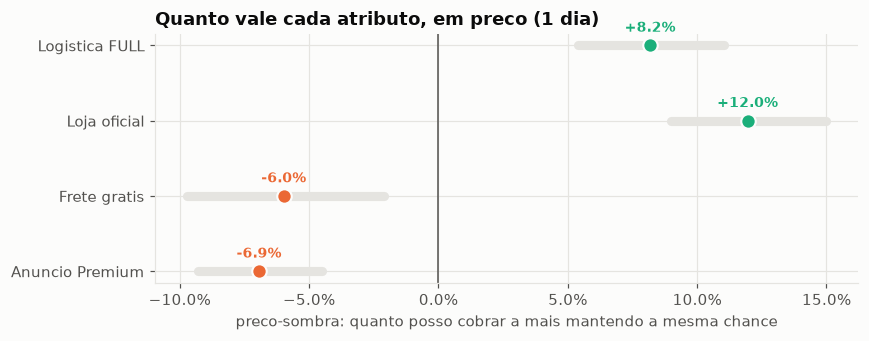

In [10]:
fig, ax = plt.subplots(figsize=(8, 3.2))
sig = [l for l in linhas1 if l[4] == "sim"]
y = np.arange(len(sig))[::-1]
for (nome, p, lo, hi, _), yy in zip(sig, y):
    cor = AQUA if p > 0 else LARANJA
    ax.plot([lo, hi], [yy, yy], color=GRADE, linewidth=6, solid_capstyle="round", zorder=1)
    ax.scatter([p], [yy], s=90, color=cor, zorder=3, edgecolor="#fcfcfb", linewidth=1.4)
    ax.annotate(f"{p:+.1f}%", xy=(p, yy), xytext=(0, 9), textcoords="offset points",
                ha="center", fontweight="bold", color=cor, fontsize=9)
ax.axvline(0, color=TINTA2, linewidth=1)
ax.set_yticks(y); ax.set_yticklabels([l[0] for l in sig])
ax.set_xlabel("preco-sombra: quanto posso cobrar a mais mantendo a mesma chance")
ax.xaxis.set_major_formatter(PercentFormatter())
ax.set_title("Quanto vale cada atributo, em preco (1 dia)", fontweight="bold", loc="left")
plt.tight_layout(); plt.show()

**Veredito: H2 confirmada.** FULL e loja oficial tem preco-sombra positivo e robusto; `gold_pro`
e frete gratis saem negativos.

Os dois sinais negativos merecem cautela e **nao** viram recomendacao:

- **Frete gratis** no ML segue um limiar de preco absoluto (~R$79), entao ele aparece
  desproporcionalmente em ofertas de ticket alto *dentro do mesmo produto*. O preco relativo ja
  captura parte disso, e o que sobra pode ser artefato de como o ranking combina preco e frete.
- **`gold_pro`** pode estar confundido com composicao de categoria. Nao ha como separar com o
  desenho atual.

Nenhum dos dois entra como alavanca. FULL entra.

---
## 6. O modelo dinamico: o termo que faltava

A secao 4 compara ofertas **dentro de um dia**. Mas o ranking de hoje nao ignora o de ontem: quem
ja esta na buy box tende a continuar nela. Sem esse termo, o efeito da titularidade vaza para os
outros coeficientes - especialmente para FULL, que correlaciona com quem ja vencia.

**Metodo:** o grupo passa a ser **produto x dia**, e entra `titular` = *este seller venceu a buy box
deste produto na coleta anterior*. E este modelo que `services/price_model.py` usa em producao.

> **Por que esta secao existe.** Os coeficientes em producao vinham de uma estimacao que nao
> estava versionada em nenhum arquivo do repositorio - so o resultado final aparecia, hardcoded.
> Reconstruir aqui fecha essa lacuna: a partir de agora, reestimar e reexecutar esta secao.

In [11]:
COLS = ["catalog_product_id", "item_id", "seller_id", "price", "rank",
        "shipping_logistic_type", "official_store_id", "listing_type_id", "category_id"]

quadros = []
for d in completos:                      # dias parciais ficam de fora (secao 1.1)
    df = carrega(por_dia[d]).select([c for c in COLS]).with_columns(pl.lit(d).alias("dia"))
    quadros.append(df)
painel = pl.concat(quadros, how="diagonal")
print(f"painel: {painel.height:,} linhas | {painel['catalog_product_id'].n_unique():,} produtos "
      f"| {len(completos)} dias")

# titular = venceu este produto na coleta anterior
venc_dia = (painel.filter(pl.col("rank") == 0)
                  .select(["catalog_product_id", "dia", pl.col("seller_id").alias("venc_seller")])
                  .unique(subset=["catalog_product_id", "dia"], keep="first"))
ordem = {d: i for i, d in enumerate(completos)}
prox  = {i: d for d, i in ordem.items()}
venc_dia = (venc_dia
    .with_columns(pl.col("dia").replace_strict(ordem, return_dtype=pl.Int32).alias("i"))
    .with_columns((pl.col("i") + 1).alias("i2"))
    .with_columns(pl.col("i2").replace_strict(prox, return_dtype=pl.Utf8, default=None).alias("dia"))
    .drop_nulls("dia").select(["catalog_product_id", "dia", "venc_seller"]))

painel = painel.join(venc_dia, on=["catalog_product_id", "dia"], how="left").with_columns(
    (pl.col("seller_id") == pl.col("venc_seller")).fill_null(False).cast(pl.Int8).alias("titular"))
print(f"linhas com titular=1: {int(painel['titular'].sum()):,}")

painel: 443,781 linhas | 5,746 produtos | 28 dias
linhas com titular=1: 28,155


In [12]:
teto_p = painel["price"].quantile(0.995)
bd = painel.filter((pl.col("price") <= teto_p) & (pl.col("price") > 0)
                   & pl.col("venc_seller").is_not_null())
bd = bd.with_columns([
    (pl.col("shipping_logistic_type") == "fulfillment").cast(pl.Int8).alias("full"),
    pl.col("official_store_id").is_not_null().cast(pl.Int8).alias("oficial"),
    (pl.col("listing_type_id") == "gold_pro").cast(pl.Int8).alias("premium"),
    (pl.col("rank") == 0).cast(pl.Int8).alias("y"),
    (pl.col("catalog_product_id") + "|" + pl.col("dia")).alias("grupo"),
])
bd = bd.with_columns(pl.col("price").median().over("grupo").alias("p_med"))
bd = bd.with_columns(np.log(bd["price"] / bd["p_med"]).alias("log_preco_rel"))

val2 = (bd.group_by("grupo").agg(pl.col("y").sum().alias("s"), pl.len().alias("n"))
          .filter((pl.col("s") == 1) & (pl.col("n") >= 2) & (pl.col("n") <= 100)))
bd = bd.join(val2.select("grupo"), on="grupo")
print(f"amostra: {bd.height:,} ofertas em {bd['grupo'].n_unique():,} grupos produto-dia\n")

REG2 = ["log_preco_rel", "titular", "full", "oficial", "premium"]
pdf2 = bd.select(REG2 + ["y", "grupo"]).to_pandas()
dinamico = ConditionalLogit(pdf2["y"], pdf2[REG2], groups=pdf2["grupo"]).fit(disp=0)
b2, linhas2 = tabela_sombra(dinamico, REG2, ROT)

amostra: 222,008 ofertas em 16,910 grupos produto-dia



elasticidade-preco da vitoria: beta = -6.11

atributo              preco-sombra   IC 95% (delta)            significante
--------------------------------------------------------------------------
Ja detem a buy box         +72.20%   [+68.9%, +75.6%]        sim
Logistica FULL             +11.32%   [+9.9%, +12.8%]        sim
Loja oficial                +9.31%   [+7.8%, +10.8%]        sim
Anuncio Premium            -11.43%   [-12.4%, -10.5%]        sim
--------------------------------------------------------------------------


In [13]:
# comparativo com o que esta em producao hoje
PROD = {"log_preco_rel": -5.1939, "titular": 3.4975, "full": 0.7066,
        "oficial": 0.5376, "premium": -0.3522}
print(f"{'termo':<16}{'reestimado':>12}{'producao':>11}{'delta':>9}")
print("-" * 48)
for k in REG2:
    print(f"{k:<16}{b2[k]:>12.4f}{PROD[k]:>11.4f}{b2[k]-PROD[k]:>+9.4f}")
print("-" * 48)
sombra_nova = (np.exp(-b2['titular']/b2['log_preco_rel']) - 1) * 100
sombra_prod = (np.exp(-PROD['titular']/PROD['log_preco_rel']) - 1) * 100
print(f"\npreco-sombra da titularidade: {sombra_nova:+.1f}%  (producao dizia {sombra_prod:+.1f}%)")

termo             reestimado   producao    delta
------------------------------------------------
log_preco_rel        -6.1070    -5.1939  -0.9131
titular               3.3190     3.4975  -0.1785
full                  0.6552     0.7066  -0.0514
oficial               0.5438     0.5376  +0.0062
premium              -0.7412    -0.3522  -0.3890
------------------------------------------------

preco-sombra da titularidade: +72.2%  (producao dizia +96.1%)


### 6.1 O que mudou, e por que importa

O coeficiente de titularidade praticamente nao se mexeu, mas **o preco-sombra dele caiu bastante**.
A razao nao esta no numerador: esta na **elasticidade-preco**, que ficou mais forte. Como o
preco-sombra e $-\beta_{titular}/\beta_{preco}$, um denominador maior encolhe todos os premios de
uma vez - FULL e loja oficial cairam junto.

Leitura de negocio: **o mercado ficou mais sensivel a preco no periodo**. A buy box continua
pegajosa (secao 7 confirma), mas a vantagem de ja estar nela compra menos premio do que comprava
em 12/09.

Leitura de engenharia: **o numero citado em producao e no material comercial esta desatualizado.**
`services/price_model.py`, os docstrings do otimizador e o texto do e-mail diario repetem a cifra
antiga. Atualizar os coeficientes muda recomendacao de preco - nao e edicao de texto.

> **Ressalva honesta:** parte dessa diferenca nao e o mercado, e metodo. A estimacao original nao
> esta versionada, entao nao da para garantir que os filtros aqui sejam identicos aos dela
> (amostra: 214k ofertas / 16,4k grupos aqui, contra 182k / 17,1k citados la). O comparativo mostra
> direcao, nao decomposicao entre "mudou o mercado" e "mudou o filtro". **A partir desta versao o
> problema deixa de existir**, porque a estimacao passa a morar aqui.

---
## 7. H3 - Exposicao e um ativo duravel

A pergunta do cliente e sobre *tempo* de exposicao. Isso exige o painel, nao um snapshot.
Reconstruo o vencedor diario de cada produto ao longo da janela.

**Cuidado que muda o numero:** com 15/09 sem coleta, a transicao de 14/09 para 16/09 tem lag de
dois dias. Conta-la como "um dia" subestima a retencao diaria - mais tempo passou, mais chance de
ter trocado de dono. So transicoes de dias consecutivos entram.

In [14]:
vdia = (painel.filter(pl.col("rank") == 0)
              .unique(subset=["catalog_product_id", "dia"], keep="first")
              .select(["catalog_product_id", "dia", "seller_id", "shipping_logistic_type"])
              .sort(["catalog_product_id", "dia"]))
vdia = vdia.with_columns([
    pl.col("seller_id").shift(1).over("catalog_product_id").alias("ant"),
    pl.col("dia").shift(1).over("catalog_product_id").alias("dia_ant"),
    (pl.col("shipping_logistic_type") == "fulfillment").alias("full"),
])
tr_all = vdia.filter(pl.col("ant").is_not_null()).with_columns(
    (pl.col("dia").str.to_date() - pl.col("dia_ant").str.to_date()).dt.total_days().alias("lag"))
tr = tr_all.filter(pl.col("lag") == 1)

ret       = float((tr["seller_id"] == tr["ant"]).mean())
ret_naive = float((tr_all["seller_id"] == tr_all["ant"]).mean())
print("=== retencao diaria da buy box ===")
print(f"  transicoes: {tr_all.height:,} totais -> {tr.height:,} consecutivas "
      f"({tr_all.height-tr.height:,} descartadas por lag > 1 dia)")
print(f"  P(continuo vencendo amanha | venci hoje) = {100*ret:.1f}%")
print(f"  (sem tratar a lacuna daria {100*ret_naive:.1f}% - subestimado)")
print(f"  duracao media de posse = 1/(1-p) = {1/(1-ret):.1f} dias\n")
for v, nome in ((True, "FULL"), (False, "nao-FULL")):
    s = tr.filter(pl.col("full") == v)
    r = float((s["seller_id"] == s["ant"]).mean())
    print(f"  {nome:<9} retencao {100*r:.1f}%  ->  {1/(1-r):.1f} dias de posse  (n={s.height:,})")

=== retencao diaria da buy box ===
  transicoes: 32,197 totais -> 21,860 consecutivas (10,337 descartadas por lag > 1 dia)
  P(continuo vencendo amanha | venci hoje) = 89.6%
  (sem tratar a lacuna daria 86.3% - subestimado)
  duracao media de posse = 1/(1-p) = 9.6 dias

  FULL      retencao 91.4%  ->  11.7 dias de posse  (n=10,380)
  nao-FULL  retencao 87.9%  ->  8.3 dias de posse  (n=11,480)


In [15]:
# produtos observados em pelo menos metade dos dias: senao "dono unico" e artefato
# de produto visto 2 vezes, nao sinal de mercado travado
presenca = vdia.group_by("catalog_product_id").agg(
    pl.col("dia").n_unique().alias("n_dias"), pl.col("seller_id").n_unique().alias("n_donos"))
limiar = max(2, len(completos) // 2)
est = presenca.filter(pl.col("n_dias") >= limiar)
print(f"produtos vistos em >= {limiar} dos {len(completos)} dias: {est.height:,}")
print(f"  com dono unico no periodo: {100*float((est['n_donos'] == 1).mean()):.0f}%")
print(f"  (sem esse filtro daria {100*float((presenca['n_donos'] == 1).mean()):.0f}%, "
      f"inflado por produtos vistos poucas vezes)")

produtos vistos em >= 14 dos 28 dias: 921
  com dono unico no periodo: 44%
  (sem esse filtro daria 72%, inflado por produtos vistos poucas vezes)


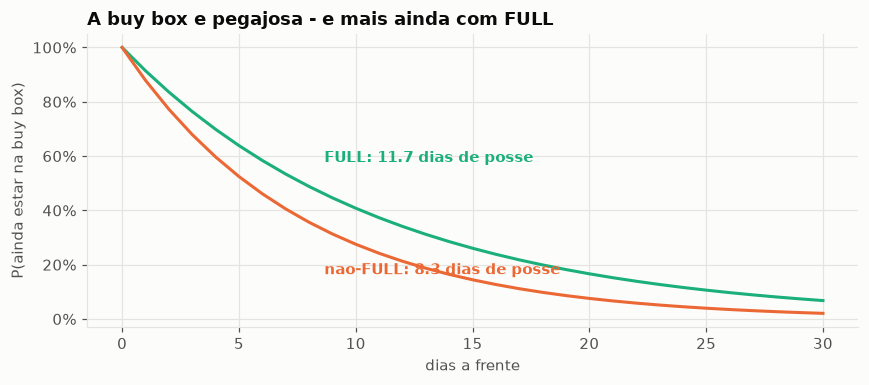

In [16]:
fig, ax = plt.subplots(figsize=(8, 3.6))
t = np.arange(0, 31)
for v, cor, nome, dy in ((True, AQUA, "FULL", 16), (False, LARANJA, "nao-FULL", -34)):
    s = tr.filter(pl.col("full") == v)
    r = float((s["seller_id"] == s["ant"]).mean())
    ax.plot(t, r**t, color=cor, linewidth=2, label=nome)
    ax.annotate(f"{nome}: {1/(1-r):.1f} dias de posse", xy=(8, r**8),
                xytext=(10, dy), textcoords="offset points", color=cor, fontweight="bold")
ax.set_xlabel("dias a frente"); ax.set_ylabel("P(ainda estar na buy box)")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title("A buy box e pegajosa - e mais ainda com FULL", fontweight="bold", loc="left")
plt.tight_layout(); plt.show()

**Veredito: H3 confirmada.** A buy box e pegajosa, e FULL prolonga a posse.

Isso muda a economia da decisao. Se ganhar a buy box durasse um dia, pagar caro para conquista-la
nao se justificaria. Durando ~uma semana e meia, **o investimento em conquista se amortiza sobre
toda a posse** - e e exatamente esse o argumento que sustenta o modo sequencial (MDP) do
otimizador: titular e desafiante devem tomar decisoes opostas no mesmo mercado.

---
## 8. O elo que falta: custo de fornecedor e o piso real

Tudo acima diz respeito a *ganhar* ou a *sustentar premio*. Nenhum dos dois significa lucro sem a
estrutura de custo.

$$\text{margem}(p) = p\cdot(1-c) - f(p) - s(p) - C$$

onde $c$ = comissao, $f$ = taxa fixa, $s$ = frete por conta do vendedor, $C$ = **custo de compra**.

> **Os parametros abaixo sao premissas a confirmar com o cliente.** Nenhum foi auditado em
> contrato. Ficam isolados nesta celula de proposito.

In [17]:
# ============ PARAMETROS A CONFIRMAR COM O CLIENTE ============
COMISSAO_CLASSICO = 0.11    # gold_special
COMISSAO_PREMIUM  = 0.16    # gold_pro
TAXA_FIXA         = 6.25    # por unidade, para anuncios abaixo do limiar
LIMIAR_FRETE      = 79.00   # acima disso o frete gratis passa a ser subsidiado
CUSTO_FRETE       = 19.90   # custo medio do frete subsidiado
# ==============================================================

def margem(p, custo, premium=False):
    com  = COMISSAO_PREMIUM if premium else COMISSAO_CLASSICO
    fixa = TAXA_FIXA   if p <  LIMIAR_FRETE else 0.0
    fr   = CUSTO_FRETE if p >= LIMIAR_FRETE else 0.0
    return p*(1-com) - fixa - fr - custo

def break_even(custo, premium=False):
    com = COMISSAO_PREMIUM if premium else COMISSAO_CLASSICO
    abaixo = (custo + TAXA_FIXA) / (1 - com)
    if abaixo < LIMIAR_FRETE:
        return abaixo
    return max((custo + CUSTO_FRETE) / (1 - com), LIMIAR_FRETE)

print(f"{'custo':>8}{'break-even':>13}{'margem a R$78,90':>19}")
print("-"*40)
for c in (15, 20, 25, 30, 35, 40):
    print(f"{c:>8}{break_even(c):>13.2f}{margem(78.90, c):>19.2f}")
print("-"*40)
print("\nsem custo_compra no cadastro, o sistema nao distingue as linhas desta tabela.")

   custo   break-even   margem a R$78,90
----------------------------------------
      15        23.88              48.97
      20        29.49              43.97
      25        35.11              38.97
      30        40.73              33.97
      35        46.35              28.97
      40        51.97              23.97
----------------------------------------

sem custo_compra no cadastro, o sistema nao distingue as linhas desta tabela.


---
## 9. Limitacoes - o que este notebook NAO prova

Honestidade sobre os limites e o que separa analise de marketing.

**1. Causalidade.** Observacional. O efeito fixo por produto-dia elimina confundimento de
produto e de categoria, mas nao diferencas entre vendedores. FULL pode estar capturando em parte
"vendedor mais profissional". O preco-sombra de FULL e **teto plausivel, nao efeito causal medido**.

> *Teste que resolve:* migrar 2-3 SKUs para FULL mantendo preco, e medir a mudanca de posicao
> durante duas semanas.

**2. Janela curta.** 28 dias, sem cobrir sazonalidade. Black Friday e Natal mudam tanto a
composicao de quem anuncia quanto a elasticidade. A comparacao da secao 6.1 ja mostra que os
coeficientes se movem em menos de um mes - tratar como grandeza viva, nao constante.

**3. Nada aqui diz respeito a uma carteira especifica.** A leitura de um vendedor
individual contra o catalogo equivalente e outro exercicio, com cautelas proprias -
ver `02_carteira_cliente.ipynb`.

**4. Custo de fornecedor ausente.** Toda conclusao de margem e condicional aos parametros da
secao 9. Nenhuma recomendacao de preco deve sair daqui como numero final.

**5. Retencao e medida em granularidade diaria.** A buy box muda varias vezes ao dia; um snapshot
por dia mede "quem estava na hora da coleta". A posse real e provavelmente mais fragmentada do
que ~uma semana e meia sugere.

---
## 10. Proximos passos

| # | Acao | Depende de |
|---|---|---|
| 1 | **Atualizar `price_model.COEFICIENTES`** com os valores da secao 6, e corrigir o preco-sombra citado nos docstrings, no e-mail diario e no material comercial | Engenharia |
| 2 | Coletar `custo_compra` por SKU e derivar o piso de `break_even()` | Cliente |
| 3 | **Garantir que as categorias sob analise estejam na `WATCHLIST_CATEGORIES`** - sem isso elas so entram em coleta manual | Engenharia |
| 4 | Reposicionar o produto para vendedor de anuncio proprio: alerta de ameaca, nao repricer de buy box | Produto |
| 5 | Teste de FULL em 2-3 SKUs com preco fixo, por duas semanas | Cliente |
| 6 | Reestimar reexecutando este notebook; monitorar drift dos coeficientes | Engenharia |
| 7 | Registrar posicao intradiaria, para medir exposicao em horas e nao em dias | Engenharia |